In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

In [2]:
tools = c('singlem', 'sylph', 'singlem_dev')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev')
)
communities = paste0('marine',as.character(0))
d1 = data.table(expand.grid(tool = tools, community = communities))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community){
    to_read = paste0('output_',tool,'/opal/',community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[, readit(tool, community), by=list(tool,community, tool2)]

In [12]:
setnames(d2, c('tool', 'community', 'tool2', 'blah', 'rank', 'metric', 'sample', 'value'))
d3 = d2[blah != 'Gold standard', .(tool, community, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [13]:
fwrite(d3, 'accuracy_results.csv')# write out bc
fwrite(d3[metric == "Bray-curtis distance"], 'bray-curtis.csv', sep='\t')

In [ ]:
s1 = dcast(d3, ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`stat_boxplot()`).”


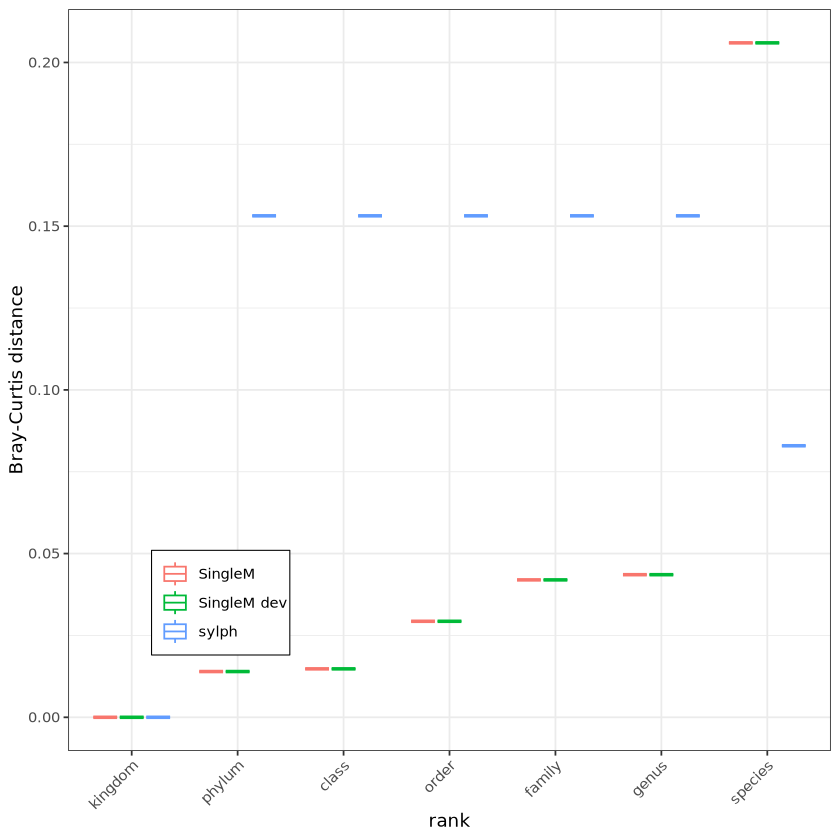

In [15]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`, colour = tool)) +
   geom_boxplot() +
   scale_x_discrete(na.translate = FALSE) +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.2,0.2)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))

# Relationship between relative abundance and accuracy

In [16]:
truth_profiles = data.table(community=communities)
truth_profiles2 = truth_profiles[, fread(paste('truths/',community,'.condensed',sep='')), by=community]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [37]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/',community,'.profile',sep='')),
    by=list(tool,community)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, tool)]
m = dcast(all_profiles, taxonomy + community ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [38]:
ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
mtmp[
    ,
    (ra_cols) := lapply(.SD[, ra_cols, with = FALSE], scales::label_percent())
][]


taxonomy,community,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
d__Bacteria,marine0,0.0000%,1.334%,1.334%,0.0000%
d__Bacteria;p__Actinobacteriota;c__Actinomycetia,marine0,0.0000%,3.005%,3.005%,0.0000%
d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales,marine0,0.0000%,1.583%,1.583%,0.0000%
d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Kineosporiaceae,marine0,0.0000%,0.117%,0.117%,0.0000%
d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Kineosporiaceae;g__Kineosporia,marine0,15.3162%,8.049%,8.049%,0.0000%
d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Kineosporiaceae;g__Kineosporia;s__Kineosporia sp018499875,marine0,0.0000%,2.668%,2.668%,0.0000%
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Flavobacteriales;f__Flavobacteriaceae;g__Flavobacterium;s__Flavobacterium hydatis,marine0,2.0106%,2.082%,2.082%,2.3856%
d__Bacteria;p__Elusimicrobiota;c__Elusimicrobia;o__Elusimicrobiales;f__Elusimicrobiaceae;g__UBA1174,marine0,0.0000%,0.323%,0.323%,0.0000%
d__Bacteria;p__Elusimicrobiota;c__Elusimicrobia;o__Elusimicrobiales;f__Elusimicrobiaceae;g__UBA1174;s__UBA1174 sp900556855,marine0,3.1778%,2.272%,2.272%,3.9597%


In [39]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
mtmp_genus = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE][
    ,
    lapply(.SD, sum),
    by = list(community, taxonomy = gsub(';s__.*','',taxonomy))
]
mtmp_genus[
    ,
    (ra_cols) := lapply(.SD[, ra_cols, with = FALSE], scales::label_percent())
][]

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,d__Bacteria,0.000%,1.334%,1.334%,0.000%
marine0,d__Bacteria;p__Actinobacteriota;c__Actinomycetia,0.000%,3.005%,3.005%,0.000%
marine0,d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales,0.000%,1.583%,1.583%,0.000%
marine0,d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Kineosporiaceae,0.000%,0.117%,0.117%,0.000%
marine0,d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Kineosporiaceae;g__Kineosporia,15.316%,10.717%,10.717%,0.000%
marine0,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Flavobacteriales;f__Flavobacteriaceae;g__Flavobacterium,2.011%,2.082%,2.082%,2.386%
marine0,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobia;o__Elusimicrobiales;f__Elusimicrobiaceae;g__UBA1174,3.178%,2.595%,2.595%,3.960%
marine0,d__Bacteria;p__Firmicutes;c__Bacilli,0.000%,0.836%,0.836%,0.000%
marine0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Erysipelotrichales;f__Coprobacillaceae;g__Beduini,1.998%,2.067%,2.067%,2.363%
